## Introduction

Finding and analyzing equilibrium points of ODE systems is a key part of stability analysis. However, finding equilibriums get increasingly difficult the more complex a system gets. Thankfully, any high order system of ODEs can be turned into a first order system of N equations with N unknowns. 

Since this system is square, Yroots can be used to search for equilibrium points within a region. Yroots prove to be especially useful in this area as Yroots can also handle non-polynomial equations, provided each equation is smooth.

Here is an example taken from the paper *Nonlinear analysis and control strategy evaluation of vehicle three degrees of freedom planar motion stability.* from 2010. In the paper, we are given a 2 Degree of Freedom (DOF) vehicle model described by the equations

<center> 

$\LARGE \dot v_y = -v_{x_{0}} \omega + \frac{F_{sf}\cos\delta_f+F_{sr}}{m}$

$\LARGE \dot \omega = \frac{F_{sf} \cos\delta_f \cdot l_f - F_{sr} \cdot l_r}{I_z}$
</center>

where $v_y$ is lateral velocity, $\omega$ is yaw velocity, $\delta_f$/$\delta_r$ is front/rear wheel steering angle, $m$ is mass of vehicle, $I_z$ is moment of inertia, $l_f$/$l_r$ is the distance from front/rear wheel to center of mass, and $F_s$ is the lateral tire force as described by the figure below.


![vehicle dynamics.png](<attachment:vehicle dynamics.png>)
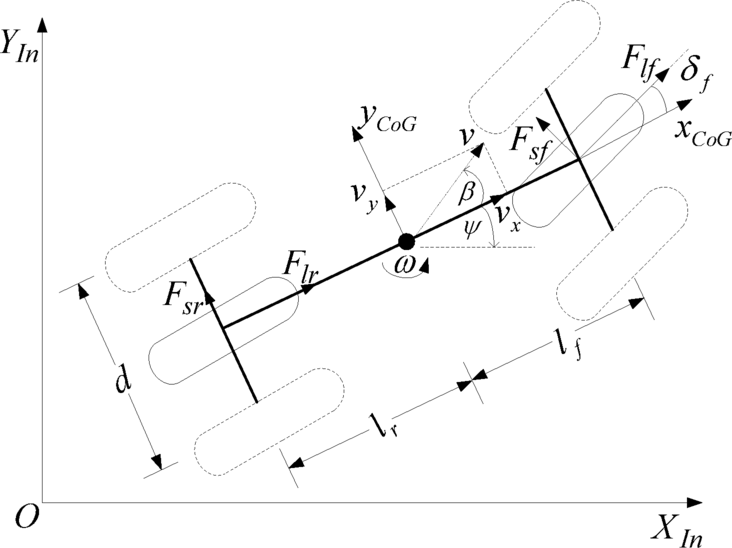

The respective force $F$ on the tires are calculated using the Pacejka's Magic Tire Formula

<center>

$F=D*sin(C*arctan(B\alpha-E(B\alpha-arctan(B\alpha))))$

</center>

and tire slip angle $\alpha$ is given by

<center>

$\large \alpha_f = \delta_f - arctan(v_y + \frac{\omega l_f}{v_x})$

$\large \alpha_r = \delta_r - arctan(v_y - \frac{\omega l_r}{v_x})$

</center>

This model is especially meaningful in that both equations utilize arctan, which cannot be solved by algorithms such as Bertini. The aforementioned paper describes a method of finding the equilibrium points of this system by utilizing a hybrid method of Genetic Algorithm and Newton’s Method. 

Below, we compare the average solve time and max residual of YRoots and a naive implementation of the hybrid method proposed by the paper.

## Setting Up the System

In [2]:
import numpy as np
import yroots as yr
from time import time
import matplotlib.pyplot as plt
import pygad

In [ ]:
# Vehicle Control Parameters
vx = 20                  # longitudinal velocity
df = 0.008               # front wheel sterring angle

# Vehicle Sturcture Parameters
d_r = 0                  # rear wheel steering angle
m = 1500                 # mass
I_z = 3000               # moment of inertia
l_f = 1.2                # distance from front wheel to center of mass
l_r = 1.3                # distance from rear wheel to center of mass

# Tire Force Parameter ([B, C, D, E])
lf_val = [11.275, 1.56, 2576.8, 0.4109]
sf_val = [11.275, 1.56, 2574.7, -1.999]
lr_val = [18.631, 1.56, 1749.6, 0.4108]
sr_val = [18.631, 1.56, 1749.7, -1.7908]

# Tire slip angle
alpha_f = lambda vy, w: df - np.arctan2((vy + w*l_f) / vx)
alpha_r = lambda vy, w: - np.arctan2((vy - w*l_r) / vx)

# Magic Formula
F = lambda B, C, D, E, alpha: D*np.sin(C*np.arctan2((1 - E)*B*alpha + E*np.arctan2(B*alpha)))

F_lf = lambda vy, w: F(*lf_val, alpha_f(vy, w))       # longitudinal tire force of the front wheels
F_sf = lambda vy, w: F(*sf_val, alpha_f(vy, w))       # lateral tire force of the front wheels
F_lr = lambda vy, w: F(*lr_val, alpha_r(vy, w))       # longitudinal tire force of the rear wheels
F_sr = lambda vy, w: F(*sr_val, alpha_r(vy, w))       # lateral tire force of the rear wheels


# Equilibrium System
f_v_y = lambda vy, w: - vx*w + (F_sf(vy, w)*np.cos(df) + F_sr(vy, w)) / m
f_w =   lambda vy, w: (F_sf(vy, w) * l_f * np.cos(df) - F_sr(vy, w) * l_r) / I_z

## Using Yroots

In [8]:
a = [-5, -1]            # Lower boundaries of v_y, omega
b = [5, 1]              # Upper boundaries of v_y, omega
funcs = [f_v_y, f_w]

yr.solve(funcs, a, b)

avg_time = 0
for _ in range(50):
    start = time()
    roots = yr.solve(funcs, a, b)
    avg_time += time() - start

print("Avg time to solve:", avg_time / 50)

residue = []
for func in funcs:
    for root in roots:
        residue.append(func(*root))

print("Max residual of solutions:", max(residue))
print("Roots:")
print(roots)

Avg time to solve: 0.29134779930114746
Max residual of solutions: 6.252776074688882e-13
Roots:
[[-0.87868266  0.12041469]
 [-0.19185052  0.04338104]
 [ 1.20053088 -0.12052591]]


## Using the hybrid method

In [9]:
funcs2 = [f_v_y, f_w]

def F_vec(x):
    vy, w = x
    return np.array([f(vy, w) for f in funcs2], dtype=float)

def numerical_jacobian(F, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    n = len(x)
    J = np.zeros((n, n))
    for j in range(n):
        e = np.zeros(n); e[j] = 1.0
        J[:, j] = (F(x + h*e) - F(x - h*e)) / (2*h)
    return J

def damped_newton(F, x0, tol=1e-10, max_iter=50):
    x = np.array(x0, dtype=float)

    def merit(r): return 0.5 * float(r @ r)

    r = F(x); phi = merit(r)
    for k in range(max_iter):
        if np.linalg.norm(r) < tol:
            return x, True

        J = numerical_jacobian(F, x)
        dx, *_ = np.linalg.lstsq(J, -r, rcond=None)

        # backtracking
        alpha = 1.0
        for _ in range(20):
            x_new = x + alpha*dx
            r_new = F(x_new)
            if merit(r_new) < phi:
                x, r, phi = x_new, r_new, merit(r_new)
                break
            alpha *= 0.5
        else:
            return x, False

    return x, False

def unique_roots(cands, eps=1e-5):
    roots = []
    for x in cands:
        if not any(np.linalg.norm(x - r) < eps for r in roots):
            roots.append(x)
    return np.array(roots)

def objective(x):
    r = F_vec(x)
    return float(r @ r)

def fitness_func(ga_instance, solution, solution_idx):
    return 1.0 / (1.0 + objective(solution))

timer = 0
for _ in range(50):
    start = time()
    ga = pygad.GA(
        num_generations=300,
        sol_per_pop=80,
        num_parents_mating=20,
        num_genes=2,
        gene_space=[{"low": -5, "high": 5},   # vy bounds
                    {"low": -1,  "high": 1}],   # w bounds
        fitness_func=fitness_func,
        random_seed=0
    )

    ga.run()

    x0, _, _ = ga.best_solution()
    timer += time() - start

    x0 = np.array(x0, dtype=float)

    start = time()
    # ---- after you run ga.run() ----
    pop = np.array(ga.population, dtype=float)         # (sol_per_pop, 2)

    # score population by residual norm (smaller = better)
    scores = np.array([np.linalg.norm(F_vec(ind)) for ind in pop])
    idx = np.argsort(scores)

    # take top K candidates and polish
    K = min(30, len(pop))
    polished = []
    for i in idx[:K]:
        x_star, ok = damped_newton(F_vec, pop[i])
        if ok and np.linalg.norm(F_vec(x_star)) < 1e-8:
            polished.append(x_star)

    polished = np.array(polished)
    roots = unique_roots(polished, eps=1e-5)

    timer += time() - start 

print(f"Average time = {timer / 50}")

residue = []
for func in funcs2:
    for root in roots:
        residue.append(func(*root))

print("Max residual of solutions:", max(residue))
print("Roots:")
print(roots)

/home/yroots/.local/lib/python3.11/site-packages/pygad/pygad.py:733: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


Average time = 1.01166841506958
Max residual of solutions: 3.8763214860182416e-11
Roots:
[[ 1.20053088 -0.12052591]
 [-0.87868266  0.12041469]
 [-0.19185052  0.04338104]]


## Graph of EQ Solutions

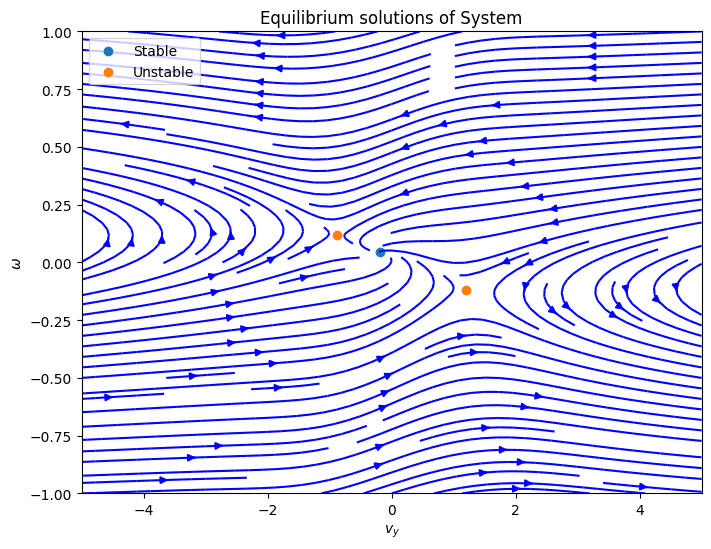

In [15]:
def numerical_jacobian(funcs, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    n = x.size
    m = len(funcs)
    J = np.zeros((m, n))
    for j in range(n):
        e = np.zeros(n); e[j] = 1.0
        xp = x + h*e
        xm = x - h*e
        fp = np.array([f(*xp) for f in funcs], dtype=float)
        fm = np.array([f(*xm) for f in funcs], dtype=float)
        J[:, j] = (fp - fm) / (2*h)
    return J

def classify_equilibria(funcs, roots, h=1e-6, tol=1e-8):
    stable = []
    unstable = []
    inconclusive = []

    for r in roots:
        J = numerical_jacobian(funcs, r, h=h)
        eig = np.linalg.eigvals(J)
        re = np.real(eig)

        if np.any(re > tol):
            unstable.append(r)
        elif np.all(re < -tol):
            stable.append(r)
        else:
            inconclusive.append(r)

    return np.array(stable), np.array(unstable), np.array(inconclusive)

stable, unstable, inconclusive = classify_equilibria(funcs, roots)

y = np.linspace(a[0], b[0], 50) 
w = np.linspace(a[1], b[1], 50)
Y, W = np.meshgrid(y, w)

dy = np.zeros_like(Y)
dw = np.zeros_like(W)

for i in range(Y.shape[0]):
    for j in range(W.shape[1]):
        # Evaluate the ODEs at each grid point (X[i, j], Y[i, j])
        y_ij = Y[i, j]
        w_ij = W[i, j]

        dy[i, j] = f_v_y(y_ij, w_ij)
        dw[i, j] = f_w(y_ij, w_ij)

# Plot the phase portrait
plt.figure(figsize=(8, 6))
plt.streamplot(Y, W, dy, dw, density=1.5, color='b', linewidth=1.5)

if stable.ndim > 1:
    plt.scatter(stable[:, 0], stable[:, 1], label="Stable")
if unstable.ndim > 1:
    plt.scatter(unstable[:, 0], unstable[:, 1], label="Unstable")
if inconclusive.ndim > 1:
    plt.scatter(inconclusive[:, 0], inconclusive[:, 1], label="Inconclusive")
plt.legend()
plt.xlabel('$v_y$')
plt.ylabel('$\omega$')
plt.title("Equilibrium solutions of System")
plt.show()
